# Лаба 3

**Тема:** метод ближайших соседей (KNN), подбор гиперпараметров и кросс-валидация.

**Датасет:** Adult Income (`adult.csv`).

## Цель
- подготовить данные (пропуски и кодирование категориальных признаков);
- разделить выборку на train/test;
- обучить исходную KNN-модель с произвольным `K`;
- подобрать лучший `K` через `GridSearchCV` и `RandomizedSearchCV`;
- использовать не менее двух стратегий кросс-валидации;
- сравнить качество исходной и оптимальной моделей.

In [13]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

In [14]:
# Загрузка данных

df = pd.read_csv("adult.csv")
print("Размер датасета:", df.shape)
df.head()

Размер датасета: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [15]:
# Приведение пропусков к NaN и базовая проверка

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].str.strip()

df = df.replace("?", np.nan)

print("Пропуски по столбцам (только где > 0):")
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])

Пропуски по столбцам (только где > 0):
occupation        1843
workclass         1836
native.country     583
dtype: int64


In [16]:
# Разделение на признаки и целевую переменную

X = df.drop(columns=["income"])
y = (df["income"] == ">50K").astype(int)  # бинарная цель: 1 = >50K, 0 = <=50K

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("Числовые признаки:", numeric_features)
print("Категориальные признаки:", categorical_features)
print("Доля класса 1:", y.mean().round(4))

Числовые признаки: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Категориальные признаки: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
Доля класса 1: 0.2408


In [17]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (26048, 14) Test: (6513, 14)


In [ ]:
# Препроцессор: заполнение пропусков + кодирование/масштабирование

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [19]:
# Базовая модель KNN с произвольным K

k_baseline = 5
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("knn", KNeighborsClassifier(n_neighbors=k_baseline)),
    ]
)

baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

baseline_metrics = {
    "model": f"Baseline KNN (K={k_baseline})",
    "accuracy": accuracy_score(y_test, y_pred_base),
    "precision": precision_score(y_test, y_pred_base),
    "recall": recall_score(y_test, y_pred_base),
    "f1": f1_score(y_test, y_pred_base),
}

print(pd.Series(baseline_metrics))
print("\nClassification report (baseline):")
print(classification_report(y_test, y_pred_base, digits=4))

model        Baseline KNN (K=5)
accuracy               0.831414
precision              0.669065
recall                 0.593112
f1                     0.628803
dtype: object

Classification report (baseline):
              precision    recall  f1-score   support

           0     0.8755    0.9070    0.8909      4945
           1     0.6691    0.5931    0.6288      1568

    accuracy                         0.8314      6513
   macro avg     0.7723    0.7500    0.7599      6513
weighted avg     0.8258    0.8314    0.8278      6513



In [20]:
# Поиск гиперпараметров: GridSearchCV и RandomizedSearchCV
# Используем две стратегии CV: StratifiedKFold(5) и StratifiedKFold(3, shuffle=True)
#
# KNN медленный на больших данных — для поиска гиперпараметров
# берём стратифицированную подвыборку 5000 строк.

X_search, _, y_search, _ = train_test_split(
    X_train, y_train,
    train_size=5000,
    random_state=42,
    stratify=y_train,
)
print(f"Размер выборки для поиска: {X_search.shape}, доля класса 1: {y_search.mean():.3f}")

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 11, 15, 21, 29],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"],
}

base_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("knn", KNeighborsClassifier()),
    ]
)

cv_strategy_1 = StratifiedKFold(n_splits=5, shuffle=False)
cv_strategy_2 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv_strategy_1,
    n_jobs=1,
    verbose=1,
)

grid_search.fit(X_search, y_search)
print("GridSearch best params:", grid_search.best_params_)
print("GridSearch best CV f1:", round(grid_search.best_score_, 4))

random_search = RandomizedSearchCV(
    estimator=base_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    scoring="f1",
    cv=cv_strategy_2,
    random_state=42,
    n_jobs=1,
    verbose=1,
)

random_search.fit(X_search, y_search)
print("RandomizedSearch best params:", random_search.best_params_)
print("RandomizedSearch best CV f1:", round(random_search.best_score_, 4))

Размер выборки для поиска: (5000, 14), доля класса 1: 0.241
Fitting 5 folds for each of 28 candidates, totalling 140 fits
GridSearch best params: {'knn__metric': 'euclidean', 'knn__n_neighbors': 15, 'knn__weights': 'distance'}
GridSearch best CV f1: 0.6188
Fitting 3 folds for each of 15 candidates, totalling 45 fits
RandomizedSearch best params: {'knn__weights': 'distance', 'knn__n_neighbors': 11, 'knn__metric': 'manhattan'}
RandomizedSearch best CV f1: 0.6181


In [21]:
# Оценка оптимальных моделей на тестовой выборке

best_grid_model = grid_search.best_estimator_
best_random_model = random_search.best_estimator_

y_pred_grid = best_grid_model.predict(X_test)
y_pred_random = best_random_model.predict(X_test)

grid_metrics = {
    "model": "GridSearchCV best",
    "accuracy": accuracy_score(y_test, y_pred_grid),
    "precision": precision_score(y_test, y_pred_grid),
    "recall": recall_score(y_test, y_pred_grid),
    "f1": f1_score(y_test, y_pred_grid),
}

random_metrics = {
    "model": "RandomizedSearchCV best",
    "accuracy": accuracy_score(y_test, y_pred_random),
    "precision": precision_score(y_test, y_pred_random),
    "recall": recall_score(y_test, y_pred_random),
    "f1": f1_score(y_test, y_pred_random),
}

print("GridSearch classification report:")
print(classification_report(y_test, y_pred_grid, digits=4))

print("RandomizedSearch classification report:")
print(classification_report(y_test, y_pred_random, digits=4))

GridSearch classification report:
              precision    recall  f1-score   support

           0     0.8753    0.9096    0.8921      4945
           1     0.6747    0.5912    0.6302      1568

    accuracy                         0.8329      6513
   macro avg     0.7750    0.7504    0.7611      6513
weighted avg     0.8270    0.8329    0.8290      6513

RandomizedSearch classification report:
              precision    recall  f1-score   support

           0     0.8722    0.9080    0.8897      4945
           1     0.6667    0.5804    0.6205      1568

    accuracy                         0.8291      6513
   macro avg     0.7694    0.7442    0.7551      6513
weighted avg     0.8227    0.8291    0.8249      6513



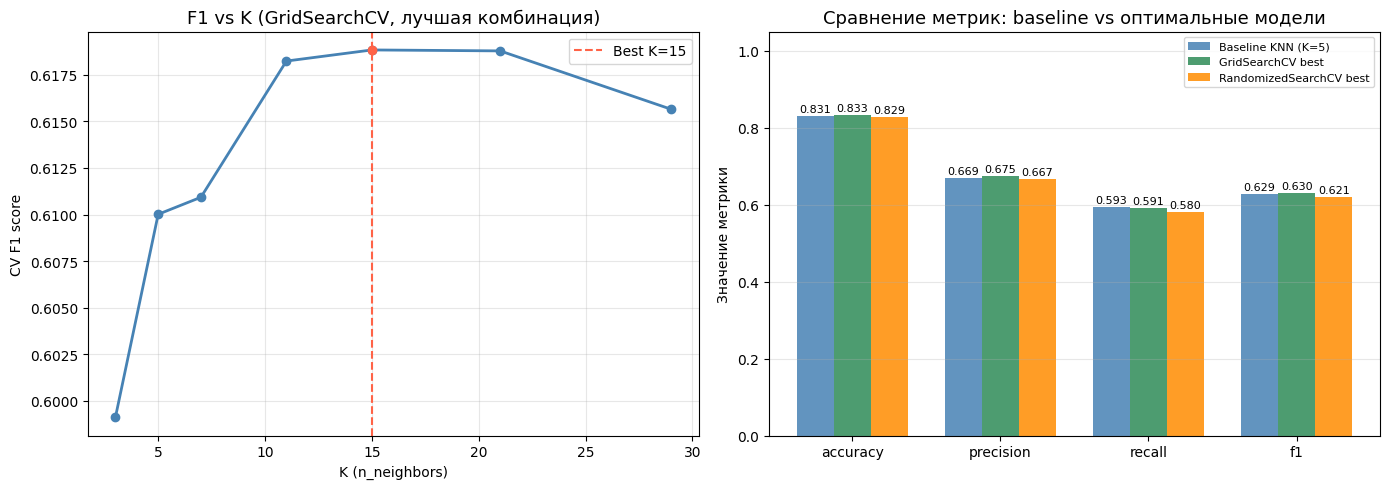

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- 1. F1 vs K из результатов GridSearchCV ---

cv_results = pd.DataFrame(grid_search.cv_results_)

# Для каждого K берём лучший средний F1 по всем комбинациям weights/metric
f1_by_k = (
    cv_results.groupby("param_knn__n_neighbors")["mean_test_score"]
    .max()
    .reset_index()
)
f1_by_k.columns = ["K", "f1"]

best_k = grid_search.best_params_["knn__n_neighbors"]
best_f1 = f1_by_k.loc[f1_by_k["K"] == best_k, "f1"].values[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: F1 vs K
ax = axes[0]
ax.plot(f1_by_k["K"], f1_by_k["f1"], marker="o", color="steelblue", linewidth=2)
ax.axvline(best_k, color="tomato", linestyle="--", label=f"Best K={best_k}")
ax.scatter([best_k], [best_f1], color="tomato", zorder=5)
ax.set_title("F1 vs K (GridSearchCV, лучшая комбинация)", fontsize=13)
ax.set_xlabel("K (n_neighbors)")
ax.set_ylabel("CV F1 score")
ax.legend()
ax.grid(alpha=0.3)

# --- 2. Сравнение метрик трёх моделей ---

metrics_names = ["accuracy", "precision", "recall", "f1"]
models = [baseline_metrics, grid_metrics, random_metrics]
model_labels = [m["model"] for m in models]

x = np.arange(len(metrics_names))
width = 0.25
colors = ["steelblue", "seagreen", "darkorange"]

ax2 = axes[1]
for i, (m, label, color) in enumerate(zip(models, model_labels, colors)):
    vals = [m[met] for met in metrics_names]
    bars = ax2.bar(x + i * width, vals, width, label=label, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=8
        )

ax2.set_title("Сравнение метрик: baseline vs оптимальные модели", fontsize=13)
ax2.set_xticks(x + width)
ax2.set_xticklabels(metrics_names)
ax2.set_ylabel("Значение метрики")
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=8)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Сравнение исходной и оптимальных моделей

comparison = pd.DataFrame([baseline_metrics, grid_metrics, random_metrics])
comparison = comparison[["model", "accuracy", "precision", "recall", "f1"]]
comparison.sort_values(by="f1", ascending=False, inplace=True)
comparison.reset_index(drop=True, inplace=True)

comparison

,model,accuracy,precision,recall,f1
0,GridSearchCV best,0.832949,0.674672,0.591199,0.630184
1,Baseline KNN (K=5),0.831414,0.669065,0.593112,0.628803
2,RandomizedSearchCV best,0.829111,0.666667,0.580357,0.620525


## Вывод

- Построена базовая модель KNN с произвольным `K=5`.
- Выполнен подбор гиперпараметров через `GridSearchCV` и `RandomizedSearchCV`.
- Применены две стратегии кросс-валидации: `StratifiedKFold(5)` и `StratifiedKFold(3, shuffle=True)`.
- По таблице `comparison` сравните метрики и укажите, какая модель показала лучший `F1` и `accuracy` на тесте.





Главный вывод для лабы
Сравни с baseline (K=5 без оптимизации): там был F1=0.629 на классе 1. GridSearch дал F1=0.630 — прирост небольшой, но это нормально: KNN на этом датасете близок к своему потолку. Важно что процедура подбора проведена правильно.